# 直流式风洞快速设计

输入：试验段尺寸要求，$1m \times 1m$， 风速要求：20m/s$\sim$80m/s，湍流度3%，速度均匀性1%，轴向静压梯度暂不要求，试验段长度6m，试验段出口为常压。

设计过程

## 试验段流动条件简要分析

1. 计算流量包线
2. 估计Re数范围
3. 估计压力损失

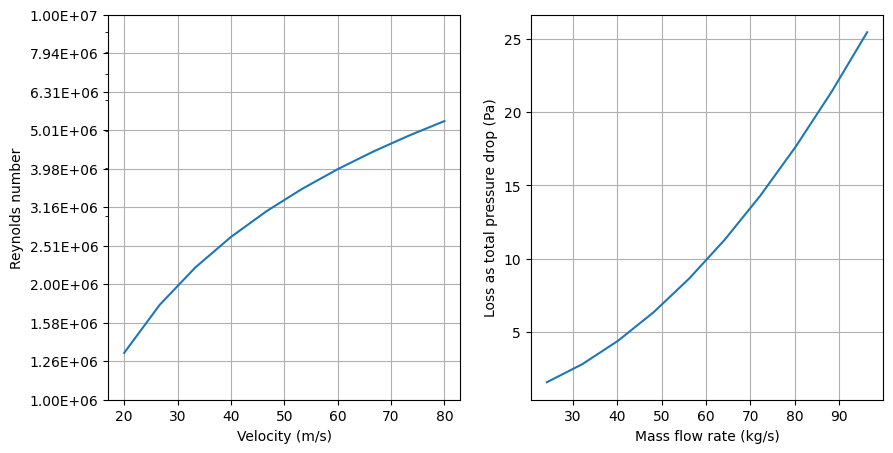

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP


# flow properties
T = 273.15 + 20
Pe = 101325
rho = CP.PropsSI('D', 'T', T, 'P', Pe, 'air')
nu = CP.PropsSI('viscosity', 'T', T, 'P', Pe, 'air')

V = np.linspace(20, 80, 10)
d = 1
L = 6
A = d * d

# mass flow rate
q = rho * V * A


plt.figure(figsize=(10, 5))
plt.tight_layout()

# Reynolds number
Re = rho * V * d / nu
plt.subplot(121)
plt.plot(V, Re)
plt.ylabel('Reynolds number')
plt.xlabel('Velocity (m/s)')
plt.yscale('log')
log_ticks = np.logspace(6, 7, 11)
plt.yticks(log_ticks, [f"{lt:.2E}" for lt in log_ticks])
plt.grid()

# Reynolds number results validate the selection of constant friction coefficient
# average fiction coefficient, only valid for Re > 1e5
eta_bar = 0.0011

# losss estimation
dp = 0.5 * rho * V * V 
deltaP = eta_bar * dp * L / d

plt.subplot(122)
plt.plot(q, deltaP)

plt.xlabel('Mass flow rate (kg/s)')
plt.ylabel('Loss as total pressure drop (Pa)')
plt.grid()


plt.show()


In [ ]:
import cadquery as cq


# create a box
model = (
    cq
    .Workplane("YZ")
    .box(d, d, L)
)

display(model)

## 核心流动设计

1. 设计收缩比
2. 设计收缩段
3. 设计稳定段
   1. 静流段
   2. 金属丝网
   3. 蜂窝器


### 收缩段


通过核心流动部段的设计，可以实现湍流度的指标，其中收缩段是一个非常重要的参数，在后续设计中是一个主要的调整对象。

设计意图：通过调整收缩比$C$，可以改变风洞：

1. 试验段湍流度
2. 风洞能量系数
3. 风洞长度
4. 风洞稳定段尺寸

这个参数在低速直流风洞是一个重要驱动参数。

这里先不讨论$C$的设计准则，我们选择$C=9$。

那么可以得到收缩段的入口面积为$A_1=9\text{m}^2$，尺寸为$3\text{m} \times 3\text{m}$，其出口与试验段入口重合。

并且，我们先随意的确定收缩段长度为5m。


风洞收缩段的双三次曲线表达为：

$$ y = \left\{
   \begin{aligned}
   & (Y_1-Y_2) \left[
      1 - \frac{L^2}{x_m^2} \left( \frac{x}{L}\right)^3
   \right] + Y_2 & 0 \leq x \leq x_m \\
   &\frac{Y_1-Y_2}{(1-x_m/L)^2}\left(
      1 - \frac{x}{L}
   \right)^3 + Y_2 & x > x_m
   \end{aligned}\right.
$$



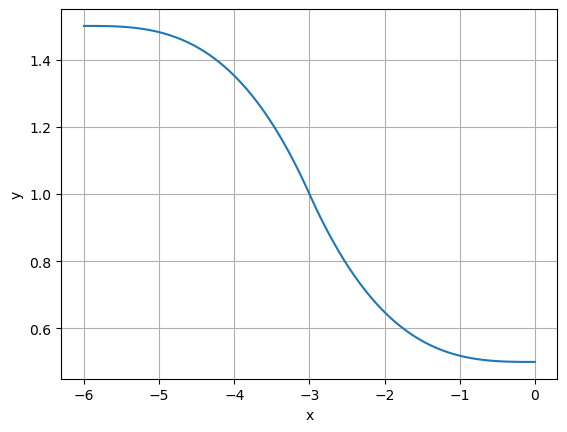

In [5]:
C = 9
L = 6


# 双三次曲线
x_m = 0.5 * L
h_1 = 0.5 * np.sqrt(C) * d
h_2 = 0.5 * d

x = np.linspace(0, L, 100)
y = np.zeros_like(x)

left_index = x <= x_m
right_index = x > x_m

y[left_index] = (h_1 - h_2) * (1 - (L/x_m) **2 * (x[left_index] / L) ** 3) + h_2
y[right_index] = (h_1 - h_2) / (1-x_m / L) ** 2  * ( 1- x[right_index]/L) ** 3 + h_2

x = x - L

plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

In [6]:
model = cq.Workplane("YZ")
# create the test section
model = model.box(d, d, L).faces("<X")

# create the contraction
for i in range(0, len(x)):
    model.workplane(offset=x[i], invert=True).rect(2 * y[i], 2 * y[i])
contraction = model.loft()

display(contraction)

### 稳定段

稳定段这里可以先只描述其流动轮廓，其中的阻尼网、蜂窝器这里先忽略，其中湍流变化的计算也在后面在进行。

In [7]:
model = cq.Workplane("YZ")
# create the test section
model = model.box(d, d, L).faces("<X")

# create the contraction
for i in range(0, len(x)):
    model.workplane(offset=x[i], invert=True).rect(2 * y[i], 2 * y[i])
contraction = model.loft()

L = 5
model = contraction.faces("<X").workplane()
model = model.rect(2*h_1, 2*h_1).extrude(L)


display(model)

In [8]:
# 在模型中添加蜂窝器和阻尼网，个数，位置参数，几何参数，等等
honecomb_position = np.asanyarray([0.5, ])
honecomb_length = np.asanyarray([0.1, ])
honecomb_width = np.asanyarray([0.015, ])
wire_net_position = np.asanyarray([0.2, 0.8, 1.0, 1.2])

# 可以采用裴海涛等发表的文章进行计算，也可以采用简化的方法进行计算

### 扩散段的设计

在试验段下方可以设计扩散段，整个设计表达概念类似。

低速风洞扩散段和试验段之间可能会存在一个压力平衡缝，也可以不设置。设置平衡缝只影响最终风洞中的静压，不影响风洞的流量。

In [13]:
model = cq.Workplane("YZ")
# create the test section
model = (
    model
    .box(d, d, L)
    .faces("<X")
)

# create the contraction
for i in range(0, len(x)):
    model.workplane(offset=x[i], invert=True).rect(2 * y[i], 2 * y[i])
contraction = model.loft()

L = 5
model = contraction.faces("<X").workplane()
model = model.rect(2*h_1, 2*h_1).extrude(L)


model = (
    model
    .faces(">X")
    .workplane(offset=0.2)
    .rect(1.0, 1.0)
    .extrude(8, taper=-2.5)
)

display(model)
